In [180]:
import torch
from torch import nn
import sklearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import pandas as pd


In [181]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [182]:
device

device(type='cpu')

In [183]:
from sklearn.datasets import make_circles

In [184]:
torch.manual_seed(42)

In [185]:
X, y = make_circles(n_samples=1000, noise=0.03)

In [186]:
X, y

(array([[-0.27585202, -0.9540073 ],
        [ 0.65402975, -0.3742546 ],
        [-0.13034662,  0.76193109],
        ...,
        [ 0.65012471, -0.7216874 ],
        [-0.93688758, -0.44640011],
        [-1.04136288,  0.02240667]]),
 array([0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1,
        1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
        0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1,
        1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
        1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
        1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
        1, 0, 1, 0, 1, 1, 1, 

In [187]:
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

In [188]:
X, y

(tensor([[-0.2759, -0.9540],
         [ 0.6540, -0.3743],
         [-0.1303,  0.7619],
         ...,
         [ 0.6501, -0.7217],
         [-0.9369, -0.4464],
         [-1.0414,  0.0224]]),
 tensor([0., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0.,
         0., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 1., 0., 1., 0.,
         0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 0., 1., 1., 0.,
         1., 1., 0., 0., 0., 1., 1., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 1.,
         1., 1., 1., 1., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 1., 1., 0.,
         0., 1., 1., 0., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1.,
         1., 0., 1., 1., 0., 0., 0., 0., 0., 1., 0., 1., 1., 1., 1., 0., 1., 1.,
         0., 0., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1.,
         0., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
         0., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0.,


In [189]:
X.shape,y.shape

(torch.Size([1000, 2]), torch.Size([1000]))

In [190]:
circles = pd.DataFrame({'x1': X[:, 0], 'x2': X[:, 1], 'labels': y})
circles.head()

,x1,x2,labels
0,-0.275852,-0.954007,0.0
1,0.654030,-0.374255,1.0
2,-0.130347,0.761931,1.0
3,-0.036719,0.766264,1.0
4,0.556082,-0.638717,1.0


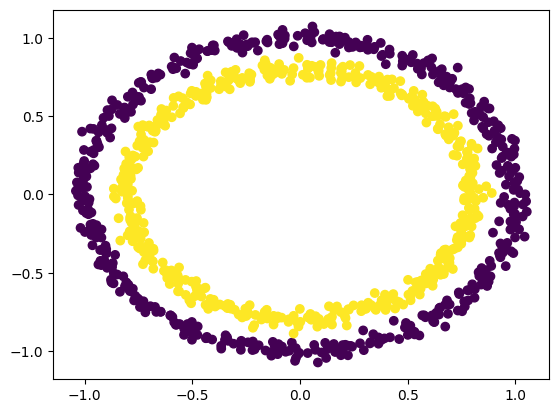

In [191]:
plt.scatter(x=X[:, 0], y=X[:, 1], c=y)

In [192]:
type(X), type(y)

(torch.Tensor, torch.Tensor)

In [193]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [194]:
X_train, X_test, y_train, y_test

(tensor([[ 0.9922,  0.0291],
         [ 0.7464, -0.2037],
         [ 0.8689, -0.5839],
         ...,
         [-0.1567,  0.9776],
         [ 0.7675, -0.1642],
         [-0.2751, -0.9913]]),
 tensor([[ 9.9657e-01,  4.1854e-02],
         [-8.6514e-01,  3.6674e-02],
         [-9.2228e-01, -2.2356e-01],
         [ 1.4821e-01, -8.2978e-01],
         [-2.1129e-01, -9.8817e-01],
         [-7.8025e-01, -6.1888e-01],
         [ 3.1555e-01,  7.6226e-01],
         [ 6.7686e-01,  4.9515e-01],
         [-9.5889e-02,  9.5866e-01],
         [-5.0818e-01,  6.4464e-01],
         [ 8.4092e-01,  5.5969e-01],
         [ 6.8040e-01,  7.5162e-01],
         [-4.3085e-01,  9.1393e-01],
         [ 6.2933e-01,  5.1510e-01],
         [ 5.7599e-01, -5.6077e-01],
         [ 7.6368e-01,  4.8394e-02],
         [-5.4292e-01,  5.5638e-01],
         [-4.0884e-01,  9.2033e-01],
         [-6.4341e-03,  8.7135e-01],
         [ 8.7390e-02, -7.9386e-01],
         [ 7.4461e-01, -1.8287e-01],
         [ 5.3098e-01, -8.7583e-0

In [195]:
circle_model_v0 = nn.Sequential(
    nn.Linear(2,10),
    nn.ReLU(),
    nn.Linear(10,10),
    nn.ReLU(),
    nn.Linear(10,1)
).to(device)

circle_model_v0

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=1, bias=True)
)

In [196]:
type(circle_model_v0)

torch.nn.modules.container.Sequential

In [197]:
list(circle_model_v0.parameters())

[Parameter containing:
 tensor([[ 0.5406,  0.5869],
         [-0.1657,  0.6496],
         [-0.1549,  0.1427],
         [-0.3443,  0.4153],
         [ 0.6233, -0.5188],
         [ 0.6146,  0.1323],
         [ 0.5224,  0.0958],
         [ 0.3410, -0.0998],
         [ 0.5451,  0.1045],
         [-0.3301,  0.1802]], requires_grad=True),
 Parameter containing:
 tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
          0.0667, -0.6984], requires_grad=True),
 Parameter containing:
 tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
           0.0346, -0.0997],
         [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
           0.1606, -0.1927],
         [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1310,  0.1000, -0.0055,
           0.2475, -0.2247],
         [ 0.0199, -0.2158,  0.0975, -0.1089,  0.0969, -0.0659,  0.2623, -0.1874,
          -0.1886, -0.1886],
         [ 0.2844,  0.1054,  0.3043, -0.2610,

In [198]:
circle_model_v0.state_dict()

OrderedDict([('0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('0.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1310,  0.1000, -0.0

In [199]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=circle_model_v0.parameters(), lr=0.03)

In [200]:
for epoch in range(1000):
  circle_model_v0.train()

  logits = circle_model_v0(X_train).squeeze()

  loss = loss_fn(logits, y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  if epoch % 100 == 0:
        with torch.no_grad():

            train_probs = torch.sigmoid(logits)

            train_predictions = (
                train_probs >= 0.5
            ).float()

            accuracy = (
                train_predictions.squeeze() == y_train
            ).float().mean()

        print(
            f"Epoch: {epoch:4d} | "
            f"Loss: {loss.item():.4f} | "
            f"Accuracy: {accuracy.item():.4f}"
        )




Epoch:    0 | Loss: 0.6930 | Accuracy: 0.4920
Epoch:  100 | Loss: 0.0091 | Accuracy: 1.0000
Epoch:  200 | Loss: 0.0034 | Accuracy: 1.0000
Epoch:  300 | Loss: 0.0019 | Accuracy: 1.0000
Epoch:  400 | Loss: 0.0012 | Accuracy: 1.0000
Epoch:  500 | Loss: 0.0008 | Accuracy: 1.0000
Epoch:  600 | Loss: 0.0006 | Accuracy: 1.0000
Epoch:  700 | Loss: 0.0005 | Accuracy: 1.0000
Epoch:  800 | Loss: 0.0004 | Accuracy: 1.0000
Epoch:  900 | Loss: 0.0003 | Accuracy: 1.0000


In [202]:
circle_model_v0.eval()

with torch.no_grad():

    test_logits = circle_model_v0(X_test)

    test_probs = torch.sigmoid(test_logits)

    test_predictions = (
        test_probs >= 0.5
    ).float()

    test_accuracy = (
        test_predictions.squeeze() == y_test
    ).float().mean()

print()
print("Test Accuracy:", test_accuracy.item())


Test Accuracy: 1.0


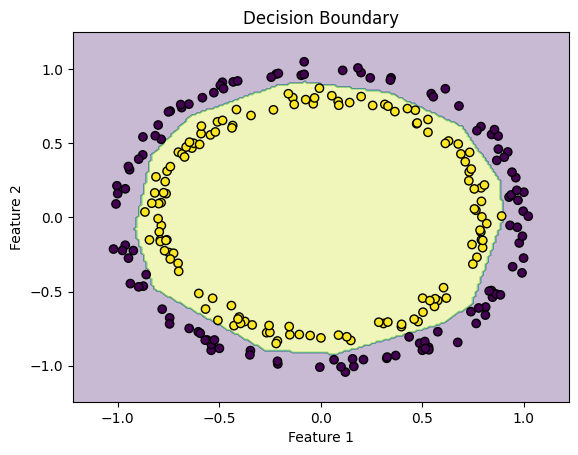

In [204]:
circle_model_v0.eval()

# Move data back to CPU for plotting
X_plot = X_test.cpu()
y_plot = y_test.cpu()

x_min = X_plot[:, 0].min() - 0.2
x_max = X_plot[:, 0].max() + 0.2

y_min = X_plot[:, 1].min() - 0.2
y_max = X_plot[:, 1].max() + 0.2


xx, yy = torch.meshgrid(
    torch.linspace(x_min, x_max, 200),
    torch.linspace(y_min, y_max, 200),
    indexing="xy"
)

grid = torch.stack(
    [xx.flatten(), yy.flatten()],
    dim=1
).to(device)


with torch.no_grad():

    grid_logits = circle_model_v0(grid)

    grid_probs = torch.sigmoid(grid_logits)

    grid_predictions = (
        grid_probs >= 0.5
    ).float()


grid_predictions = grid_predictions.cpu().reshape(xx.shape)


plt.contourf(
    xx.numpy(),
    yy.numpy(),
    grid_predictions.numpy(),
    alpha=0.3
)

plt.scatter(
    X_plot[:, 0],
    X_plot[:, 1],
    c=y_plot,
    edgecolors="black"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Decision Boundary")

plt.show()